# Taiwanese Banking Act 72-2 Analysis

Taiwan's Banking Act Article 72-2 caps the total amount of real estate loans
(mortgages, construction loans, and land loans) that a bank can issue at **30%
of its total deposits plus financial debentures**.

The regulation exists to prevent banks from over-concentrating lending in
real estate, this came form a lesson learned from past property bubbles. As of late 2024,
public banks have raised mortgage rates to between 2.185% and 3.5%, partly
because tighter lending quotas are forcing stricter credit review conditions.

**Research Question: As housing loan demand grows, are Taiwanese banks
approaching this 30% legal ceiling?**

## The Banking Act of Taiwan 72-2
The total amount of loans extended for residential construction and business construction by a commercial bank shall not exceed thirty percent (30%) of the total balance of its received deposits and issued bank debentures at the time such loans are extended; provided, that the following shall not be subject to such limitation:
1. Housing savings and loans approved by the competent authority for the encouragement of savings to facilitate the purchase of self-use residence;
2. Housing loans using deposits redeposited from postal savings allocated by the Central Bank of the Republic of China;
3. Loans using medium-and long-term funds from the National Development Council to facilitate citizens’ purchase of residence;
4. Business construction loans using medium-term and long-term funds from the National Development Fund, Executive Yuan and the National Development Council;
5. Mandated loans for purposes of encouraging investment in the construction of public housing, public housing loans and loans for facilitating the purchase of self-use residence by government employees and teachers.

A maximum amount of the loans under the provisos to the preceding paragraph may, when necessary, be prescribed by the competent authority.

## Data Processing

In [1]:
import pandas as pd
df = pd.read_csv('Presentation Data V1.csv')
df

,Date,CL- House Purchasing,CL- Car Loan,CL- Others,Construction Loan,Households,Population,Monthly GDP per person,Monthly Average Personal Income
0,2000M01,2529594000000,47340000000,442924000000,582281000000,6541419,22106240,37571,33666
1,2000M02,2521279000000,47341000000,448484000000,583331000000,6549023,22119943,37571,33666
2,2000M03,2527972000000,47417000000,451614000000,575951000000,6562307,22134777,37571,33666
3,2000M04,2549127000000,47664000000,438108000000,575106000000,6575670,22146733,37735,33457
4,2000M05,2553736000000,48013000000,449033000000,577078000000,6592549,22159658,37735,33457
...,...,...,...,...,...,...,...,...,...
293,2024M06,10540479000000,232234000000,1361368000000,3372636000000,9309862,23412899,88736,77469
294,2024M07,10656996000000,233950000000,1371447000000,3344876000000,9323985,23409323,91628,79532
295,2024M08,10748824000000,234768000000,1379972000000,3411981000000,9343388,23406608,91628,79532
296,2024M09,10859998000000,235162000000,1387826000000,3443852000000,9379019,23404138,91628,79532


In [2]:
df['Housing Loan Sum'] = df['CL- House Purchasing'] + df['Construction Loan']
df

,Date,CL- House Purchasing,CL- Car Loan,CL- Others,Construction Loan,Households,Population,Monthly GDP per person,Monthly Average Personal Income,Housing Loan Sum
0,2000M01,2529594000000,47340000000,442924000000,582281000000,6541419,22106240,37571,33666,3111875000000
1,2000M02,2521279000000,47341000000,448484000000,583331000000,6549023,22119943,37571,33666,3104610000000
2,2000M03,2527972000000,47417000000,451614000000,575951000000,6562307,22134777,37571,33666,3103923000000
3,2000M04,2549127000000,47664000000,438108000000,575106000000,6575670,22146733,37735,33457,3124233000000
4,2000M05,2553736000000,48013000000,449033000000,577078000000,6592549,22159658,37735,33457,3130814000000
...,...,...,...,...,...,...,...,...,...,...
293,2024M06,10540479000000,232234000000,1361368000000,3372636000000,9309862,23412899,88736,77469,13913115000000
294,2024M07,10656996000000,233950000000,1371447000000,3344876000000,9323985,23409323,91628,79532,14001872000000
295,2024M08,10748824000000,234768000000,1379972000000,3411981000000,9343388,23406608,91628,79532,14160805000000
296,2024M09,10859998000000,235162000000,1387826000000,3443852000000,9379019,23404138,91628,79532,14303850000000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 298 entries, 0 to 297
Data columns (total 10 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Date                             298 non-null    object
 1   CL- House Purchasing             298 non-null    int64 
 2   CL- Car Loan                     298 non-null    int64 
 3   CL- Others                       298 non-null    int64 
 4   Construction Loan                298 non-null    int64 
 5   Households                       298 non-null    int64 
 6   Population                       298 non-null    int64 
 7   Monthly GDP per person           298 non-null    int64 
 8   Monthly Average Personal Income  298 non-null    int64 
 9   Housing Loan Sum                 298 non-null    int64 
dtypes: int64(9), object(1)
memory usage: 23.4+ KB


In [4]:
df.describe()

,CL- House Purchasing,CL- Car Loan,CL- Others,Construction Loan,Households,Population,Monthly GDP per person,Monthly Average Personal Income,Housing Loan Sum
count,2.980000e+02,2.980000e+02,2.980000e+02,2.980000e+02,2.980000e+02,2.980000e+02,298.000000,298.000000,2.980000e+02
mean,5.576173e+12,1.131843e+11,8.471021e+11,1.463513e+12,8.018937e+06,2.311199e+07,56600.936242,49146.077181,7.039686e+12
std,2.162206e+12,4.826923e+10,2.439968e+11,8.631436e+11,8.011886e+05,4.166146e+05,14673.654910,12394.836144,3.018169e+12
min,2.521279e+12,4.734000e+10,4.381080e+11,3.898280e+11,6.541419e+06,2.210624e+07,36435.000000,32122.000000,3.103923e+12
25%,4.006855e+12,7.083700e+10,6.852948e+11,6.772482e+11,7.310562e+06,2.279262e+07,44574.250000,39294.000000,4.684104e+12
50%,5.305316e+12,1.138515e+11,8.133390e+11,1.435730e+12,8.109032e+06,2.321482e+07,52389.000000,45432.000000,6.743024e+12
75%,6.831923e+12,1.387858e+11,9.703938e+11,1.780774e+12,8.704850e+06,2.345551e+07,65328.000000,56707.000000,8.612697e+12
max,1.092927e+13,2.351620e+11,1.393589e+12,3.459604e+12,9.425080e+06,2.360426e+07,91628.000000,79532.000000,1.438887e+13


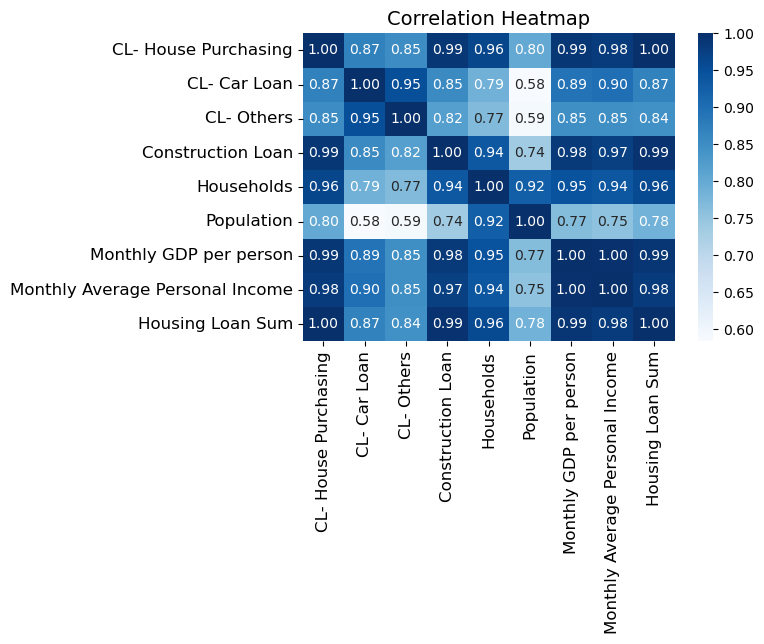

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.figure(figsize=(6,4))

numeric_columns = df.select_dtypes(include=np.number).columns

correlation_matrix = df[numeric_columns].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt='.2f')
plt.xticks(rotation=90, fontsize=12)
plt.yticks(fontsize=12)
plt.title('Correlation Heatmap', fontsize=14)
plt.show()

## Why Households? The Demand-Side Driver

Taiwan's number of registered households has grown from ~6.5 million in 2000
to over 9.4 million by October 2024 — an increase of **44% over 24 years**.

Unlike population (which has been flat or declining since ~2020), household
count continues to rise due to smaller average household sizes and urbanization.
This makes **households a stronger predictor of housing loan demand than
population** — more households means more mortgage applicants, regardless of
whether the overall population is growing.

This motivates using household count as the primary feature in our predictive model.

## Households Linear Regression Model

In [6]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [7]:
dflr = df.loc[:,['Households','Housing Loan Sum']]

dflr

,Households,Housing Loan Sum
0,6541419,3111875000000
1,6549023,3104610000000
2,6562307,3103923000000
3,6575670,3124233000000
4,6592549,3130814000000
...,...,...
293,9309862,13913115000000
294,9323985,14001872000000
295,9343388,14160805000000
296,9379019,14303850000000


In [47]:
date_range = pd.date_range(start="2000-01", end="2024-11", freq='M') 
dfd = pd.DataFrame({
    'Date': date_range
})
dfd

,Date
0,2000-01-31
1,2000-02-29
2,2000-03-31
3,2000-04-30
4,2000-05-31
...,...
293,2024-06-30
294,2024-07-31
295,2024-08-31
296,2024-09-30


In [10]:
dft = pd.concat([dfd,dflr], axis = 1)
dft

,Date,Households,Housing Loan Sum
0,2000-01-31,6541419,3111875000000
1,2000-02-29,6549023,3104610000000
2,2000-03-31,6562307,3103923000000
3,2000-04-30,6575670,3124233000000
4,2000-05-31,6592549,3130814000000
...,...,...,...
293,2024-06-30,9309862,13913115000000
294,2024-07-31,9323985,14001872000000
295,2024-08-31,9343388,14160805000000
296,2024-09-30,9379019,14303850000000


(array([27., 27., 32., 25., 26., 28., 38., 39., 37., 19.]),
 array([6541419. , 6829785.1, 7118151.2, 7406517.3, 7694883.4, 7983249.5,
        8271615.6, 8559981.7, 8848347.8, 9136713.9, 9425080. ]),
 <BarContainer object of 10 artists>)

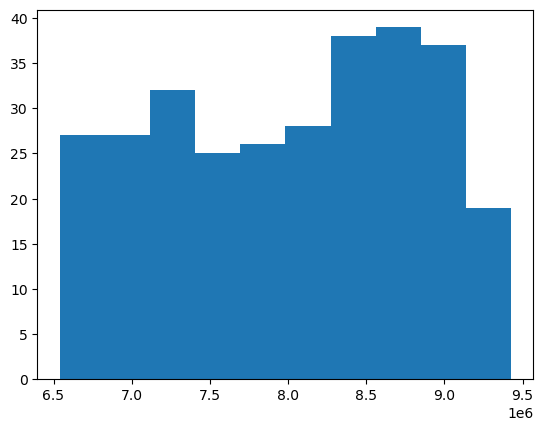

In [11]:
plt.hist(dft['Households'])

In [12]:
A = dft[['Households']]
b = dft['Housing Loan Sum']

A_train, A_test, b_train, b_test = train_test_split(A, b, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(A_train, b_train)
b_pred = model.predict(A_test)
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

print("Mean Squared Error:", mean_squared_error(b_test, b_pred))
print("R² Score:", r2_score(b_test, b_pred))

Intercept: -22068032799582.85
Coefficients: [3631051.94426256]
Mean Squared Error: 6.057178623326526e+23
R² Score: 0.9218395804295265


In [13]:
W = model.coef_
B = model.intercept_

In [14]:
lnrgmodel =  W*A + B 

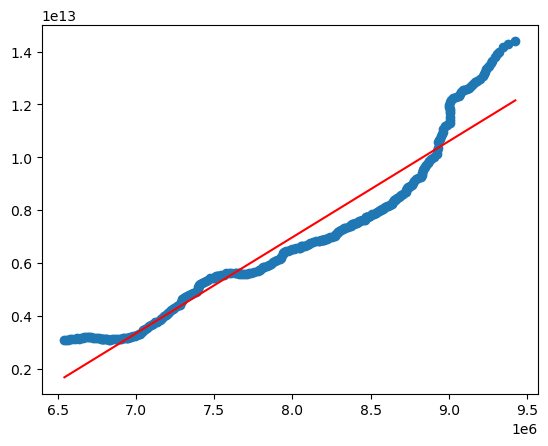

In [15]:
plt.scatter(A,b)
plt.plot(A, lnrgmodel , 'r')
plt.show()

In [16]:
results = pd.DataFrame({'Actual': b_test, 'Predicted': b_pred})
results

,Actual,Predicted
159,6898879000000,7.745976e+12
264,11770175000000,1.063232e+13
254,10790767000000,1.043184e+13
9,3185432000000,2.115692e+12
77,4812034000000,4.575297e+12
234,9164502000000,9.845116e+12
93,5446269000000,5.155950e+12
109,5590827000000,5.782470e+12
5,3144658000000,1.933279e+12
172,7279213000000,8.144810e+12


In [73]:
dft_lrpredict = dft['Households'].apply(lambda x: W * x + B )
dft_lrpredict = pd.DataFrame({'Date':date_range,'Predicted Housing Loan Sum':dft_lrpredict})
dft_lrpredict

,Date,Predicted Housing Loan Sum
0,2000-01-31,[1684199378603.1836]
1,2000-02-29,[1711809897587.3555]
2,2000-03-31,[1760044791614.9414]
3,2000-04-30,[1808566538746.121]
4,2000-05-31,[1869855064513.3281]
...,...,...
293,2024-06-30,[11736559716333.254]
294,2024-07-31,[11787841062942.07]
295,2024-08-31,[11858294363816.598]
296,2024-09-30,[11987672375642.617]


## Population Linear Regression Model

In [17]:
data = pd.read_csv('LSTM Data Set.csv')
data

,Date,Population,Households,Housing Loan Sum
0,2000-01-31,22106240,6541419,3111875000000
1,2000-02-29,22119943,6549023,3104610000000
2,2000-03-31,22134777,6562307,3103923000000
3,2000-04-30,22146733,6575670,3124233000000
4,2000-05-31,22159658,6592549,3130814000000
...,...,...,...,...
293,2024-06-30,23412899,9309862,13913115000000
294,2024-07-31,23409323,9323985,14001872000000
295,2024-08-31,23406608,9343388,14160805000000
296,2024-09-30,23404138,9379019,14303850000000


In [18]:
C = data[['Population']]
d = data['Housing Loan Sum']

C_train, C_test, d_train, d_test = train_test_split(C, d, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(C_train, d_train)
d_pred = model.predict(C_test)
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

print("Mean Squared Error:", mean_squared_error(d_test, d_pred))
print("R² Score:", r2_score(d_test, d_pred))

Intercept: -124394181990935.89
Coefficients: [5689098.87131079]
Mean Squared Error: 2.745285187026327e+24
R² Score: 0.645754805327595


In [19]:
W2 = model.coef_
B2 = model.intercept_
line_model2 = W2*C + B2

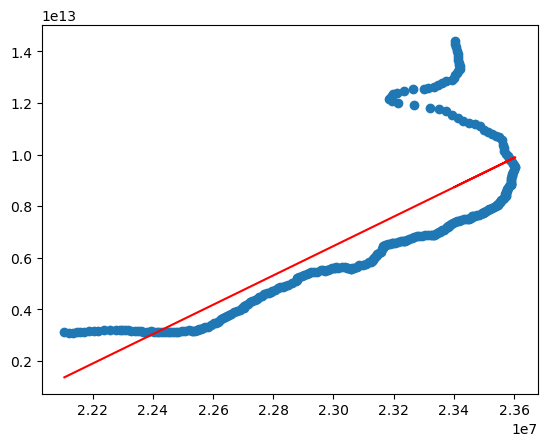

In [20]:
plt.scatter(C,d)
plt.plot(C, line_model2 , 'r')
plt.show()

In [55]:
pl_lrpredict = data['Population'].apply(lambda x: W2 * x + B2 )
pl_lrpredict = pd.DataFrame({'Date':date_range,'Population Predicted Housing Loan Sum':pl_lrpredict})
pl_lrpredict

,Date,Population Predicted Housing Loan Sum
0,2000-01-31,[1370403041989.5312]
1,2000-02-29,[1448360763823.0938]
2,2000-03-31,[1532752856480.125]
3,2000-04-30,[1600771722585.5156]
4,2000-05-31,[1674303325497.2031]
...,...,...
293,2024-06-30,[8804115284077.61]
294,2024-07-31,[8783771066513.8125]
295,2024-08-31,[8768325163078.203]
296,2024-09-30,[8754273088866.0625]


In [22]:
tdp = pd.read_csv('2000 Total Deposit.csv')

tdp

,Total Deposit
0,182688.0
1,183669.0
2,185259.0
3,185052.0
4,184089.0
...,...
293,618616.0
294,620536.0
295,618579.0
296,618212.0


In [23]:
tdp = tdp[['Total Deposit']] * 100000000

In [24]:
tdp

,Total Deposit
0,1.826880e+13
1,1.836690e+13
2,1.852590e+13
3,1.850520e+13
4,1.840890e+13
...,...
293,6.186160e+13
294,6.205360e+13
295,6.185790e+13
296,6.182120e+13


In [27]:
tdpcap = tdp *0.3

In [28]:
tdpcap

,Total Deposit
0,5.480640e+12
1,5.510070e+12
2,5.557770e+12
3,5.551560e+12
4,5.522670e+12
...,...
293,1.855848e+13
294,1.861608e+13
295,1.855737e+13
296,1.854636e+13


In [53]:
tdpcap.columns = ['Total Deposit Cap']
tdpcap

,Total Deposit Cap
0,5.480640e+12
1,5.510070e+12
2,5.557770e+12
3,5.551560e+12
4,5.522670e+12
...,...
293,1.855848e+13
294,1.861608e+13
295,1.855737e+13
296,1.854636e+13


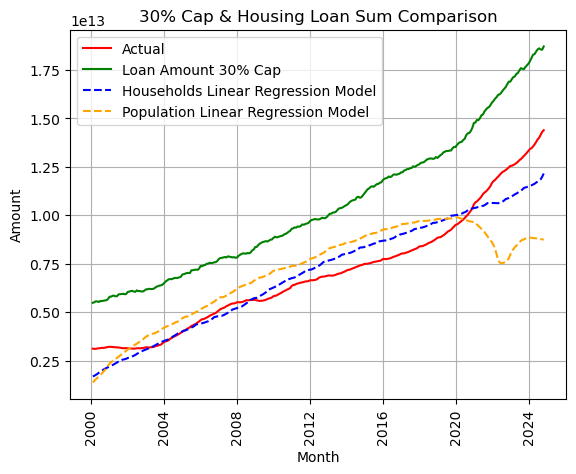

In [74]:
plt.plot(dft['Date'], data['Housing Loan Sum'], label="Actual", color='red')
plt.plot(dft['Date'], tdpcap['Total Deposit Cap'], label="Loan Amount 30% Cap", color='green')
plt.plot(dft['Date'], dft_lrpredict['Predicted Housing Loan Sum'], label="Households Linear Regression Model", color = 'blue', linestyle='--')
plt.plot(dft['Date'], pl_lrpredict['Population Predicted Housing Loan Sum'], label="Population Linear Regression Model", color = 'orange', linestyle='--')

plt.title("30% Cap & Housing Loan Sum Comparison")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.xticks(rotation=90)
plt.legend()
plt.grid(True)

plt.show()

## Normalized Household Linear Regression Model

In [32]:
from sklearn.preprocessing import MinMaxScaler

In [33]:
dft.dtypes

Date                datetime64[ns]
Households                   int64
Housing Loan Sum             int64
dtype: object

In [34]:
scaler = MinMaxScaler()
dflr_normalized = pd.DataFrame(scaler.fit_transform(dflr), columns=dflr.columns)
dflr_normalized 

,Households,Housing Loan Sum
0,0.000000,0.000705
1,0.002637,0.000061
2,0.007244,0.000000
3,0.011878,0.001800
4,0.017731,0.002383
...,...,...
293,0.960045,0.957841
294,0.964942,0.965706
295,0.971671,0.979790
296,0.984027,0.992466


In [35]:
X = dflr_normalized[['Households']]
y = dflr_normalized['Housing Loan Sum']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

Intercept: -0.12580681539544308
Coefficients: [0.92784841]
Mean Squared Error: 0.004756320403108304
R² Score: 0.9218395804295265


# LSTM Model Predicting Loan Values Based on Household as a Feature

In [36]:
pip install keras 

Note: you may need to restart the kernel to use updated packages.


In [37]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import LSTM, Dense

In [39]:
df = dft

In [40]:
df.set_index('Date', inplace=True)

In [41]:
df

,Households,Housing Loan Sum
Date,,
2000-01-31,6541419,3111875000000
2000-02-29,6549023,3104610000000
2000-03-31,6562307,3103923000000
2000-04-30,6575670,3124233000000
2000-05-31,6592549,3130814000000
...,...,...
2024-06-30,9309862,13913115000000
2024-07-31,9323985,14001872000000
2024-08-31,9343388,14160805000000


In [43]:
features = df[['Households']].values
target = df['Housing Loan Sum'].values.reshape(-1, 1)

scaler_features = MinMaxScaler()
scaler_target = MinMaxScaler()

features_scaled = scaler_features.fit_transform(features)
target_scaled = scaler_target.fit_transform(target)

def create_sequences(features, target, time_steps):
    X, y = [], []
    for i in range(len(features) - time_steps):
        X.append(features[i:i + time_steps])
        y.append(target[i + time_steps])
    return np.array(X), np.array(y)

time_steps = 2
X, y = create_sequences(features_scaled, target_scaled, time_steps)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = Sequential([
    LSTM(50, return_sequences=True, activation='relu', input_shape=(X.shape[1], X.shape[2])),
    LSTM(30, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')


history = model.fit(X_train, y_train, validation_split=0.2, epochs=20, batch_size=1, verbose=1)


y_pred_scaled = model.predict(X_test)
y_pred = scaler_target.inverse_transform(y_pred_scaled)
y_test_original = scaler_target.inverse_transform(y_test)

Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0570 - val_loss: 0.0123
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0043 - val_loss: 0.0037
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0030 - val_loss: 0.0046
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0030 - val_loss: 0.0026
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0028 - val_loss: 0.0042
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0029 - val_loss: 0.0025
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0027 - val_loss: 0.0020
Epoch 8/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0027 - val_loss: 0.0025
Epoch 9/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0025 - val_loss: 0.0026
Epoch 10/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0029 - val_loss: 0.0019
Epoch 11/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0027 - val_loss: 0.0017
Epoch 12/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

In [44]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred))
mae = mean_absolute_error(y_test_original, y_pred)

print(f"Test RMSE: {rmse:.2f}")
print(f"Test MAE: {mae:.2f}")

Test RMSE: 364151867374.38
Test MAE: 279034416276.27


In [41]:
mean_target = np.mean(y_test_original)
relative_rmse = (rmse / mean_target) * 100
relative_mae = (mae / mean_target) * 100

print(f"Relative RMSE: {relative_rmse:.2f}%")
print(f"Relative MAE: {relative_mae:.2f}%")

Relative RMSE: 5.64%
Relative MAE: 4.71%


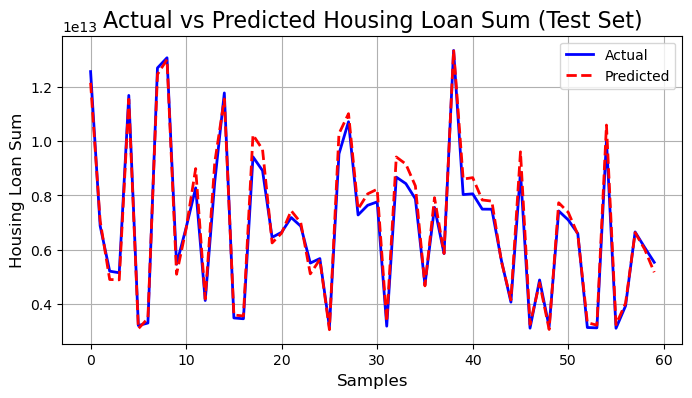

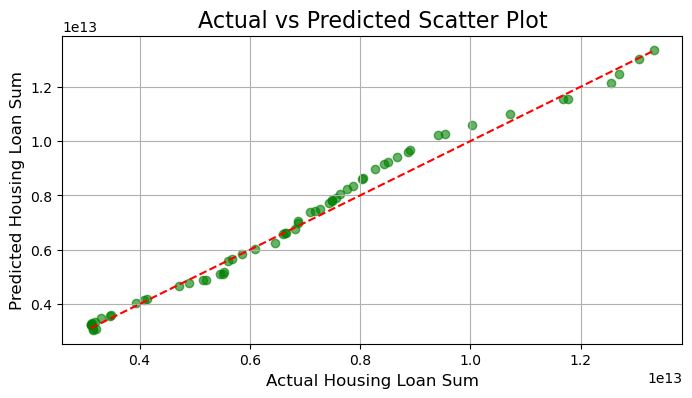

In [49]:
plt.figure(figsize=(8, 4))
plt.plot(range(len(y_test_original)), y_test_original, label='Actual', color='blue', linewidth=2)
plt.plot(range(len(y_pred)), y_pred, label='Predicted', color='red', linestyle='--', linewidth=2)
plt.title('Actual vs Predicted Housing Loan Sum (Test Set)', fontsize=16)
plt.xlabel('Samples', fontsize=12)
plt.ylabel('Housing Loan Sum', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.scatter(y_test_original, y_pred, color='green', alpha=0.6)
plt.plot([min(y_test_original), max(y_test_original)], [min(y_test_original), max(y_test_original)], color='red', linestyle='--')
plt.title('Actual vs Predicted Scatter Plot', fontsize=16)
plt.xlabel('Actual Housing Loan Sum', fontsize=12)
plt.ylabel('Predicted Housing Loan Sum', fontsize=12)
plt.grid(True)
plt.show()

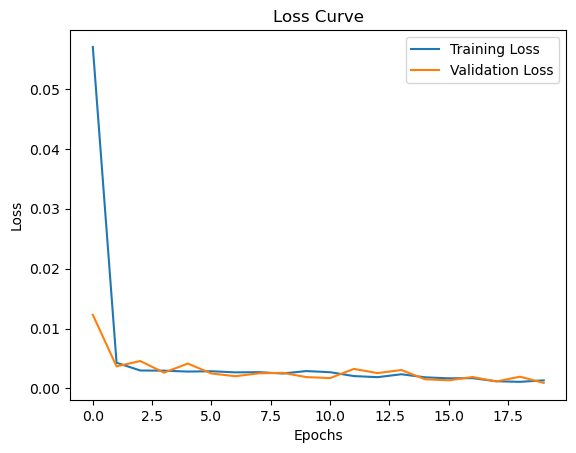

In [50]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [51]:
new_data_batch = np.array([[9475080]])
for i, new_data in enumerate(new_data_batch):
    new_data_scaled = scaler_features.transform([new_data])
    recent_data_scaled = features_scaled[-(time_steps - 1):]
    new_input_scaled = np.vstack([recent_data_scaled, new_data_scaled])
    new_input_scaled = new_input_scaled.reshape(1, time_steps, -1)
    predicted_scaled = model.predict(new_input_scaled)
    predicted_original = scaler_target.inverse_transform(predicted_scaled)
    print(f"Prediction {i+1}: {predicted_original[0][0]:,.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Prediction 1: 15,073,024,147,456.00


In [79]:
print ("Prediction error=", 15170003795968 - 14388873000000)

Prediction error= 781130795968


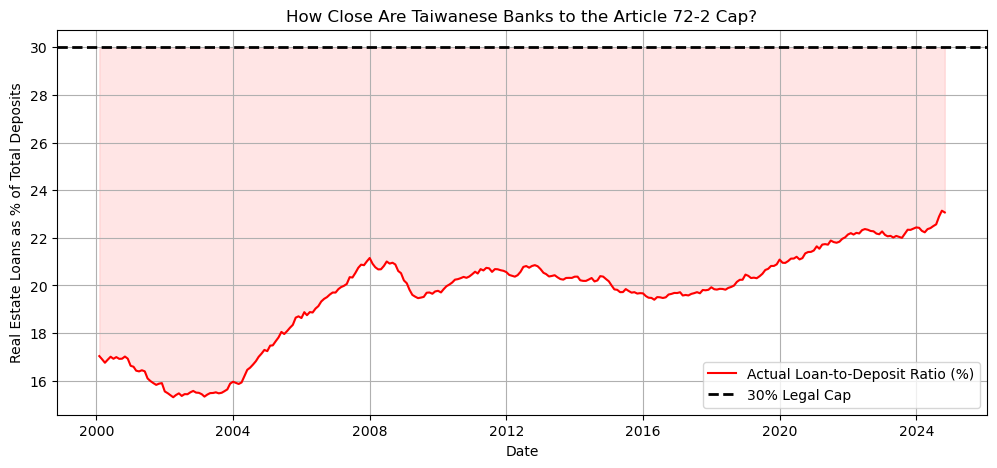

Current ratio (Oct 2024): 23.06%
Remaining headroom: 6.94 percentage points


In [80]:
actual_ratio = (data['Housing Loan Sum'] / tdp['Total Deposit']) * 100

plt.figure(figsize=(12, 5))
plt.plot(dft['Date'], actual_ratio, color='red', label='Actual Loan-to-Deposit Ratio (%)')
plt.axhline(y=30, color='black', linestyle='--', linewidth=2, label='30% Legal Cap')
plt.fill_between(dft['Date'], actual_ratio, 30, alpha=0.1, color='red')
plt.title('How Close Are Taiwanese Banks to the Article 72-2 Cap?')
plt.ylabel('Real Estate Loans as % of Total Deposits')
plt.xlabel('Date')
plt.legend()
plt.grid(True)
plt.show()

print(f"Current ratio (Oct 2024): {actual_ratio.iloc[-1]:.2f}%")
print(f"Remaining headroom: {30 - actual_ratio.iloc[-1]:.2f} percentage points")

## Regulatory Context: Is There Room to Grow?

As of July 2024, Taiwan's Financial Supervisory Commission (FSC) clarified
that Article 72-2 is designed as a **dynamic ratio control**, not a hard
quota with a fixed ceiling amount. The denominator (total deposits + financial
debentures) grows continuously, so headroom is always being created.

Key figures from the FSC (July 2024):
- **Denominator:** ~55.85 trillion TWD (total deposits + debentures)
- **Numerator:** ~14.79 trillion TWD (mortgages + construction + commercial loans)
- **Current ratio:** ~26.47% — approximately **3 percentage points below the cap**

The FSC stated it has no plans to revise the 30% limit, and that there is
currently no "full capacity" problem.

## Conclusion

Based on data from January 2000 to October 2024, Taiwanese banks are **not
yet at the Article 72-2 ceiling**, but the gap is narrowing.

The housing loan-to-deposit ratio has risen steadily from ~17% in 2000 to
approximately **23–26% in 2024**, depending on which loan categories are
included. The FSC's own estimate places the all-in ratio (including
construction and commercial real estate) at 26.47% as of July 2024 —
roughly 3 percentage points from the legal limit.

Our household-based linear regression (R² = 0.92) outperforms the
population-based model (R² = 0.65), confirming that household formation
is the key structural driver of mortgage demand. The LSTM model projects
continued growth, suggesting the ratio will keep climbing as long as
household formation outpaces deposit growth.

**The short answer: banks have headroom, but the buffer is shrinking.**